# Лабораторная работа №2

### Многоканальная система массового обслуживания с ожиданием (M/M/n/∞)

### Задачи:
- Разработать имитационную модель многоканальной системы с ожиданием.
- Провести эксперименты с различными параметрами системы.
- Проанализировать полученные результаты и сделать выводы.

### ヾ(⌐■_■)ノ♪

In [49]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
from math import factorial

np.random.seed(42)
sns.set_theme(style="whitegrid")

## Параметры системы

- λ (lambda) — интенсивность входящего потока заявок
- n — количество каналов обслуживания
- μ (mu) — интенсивность обслуживания каждого канала
- T — время моделирования

In [ ]:
# Параметры системы M/M/n/∞
lam = 10      
mu = 3        
n_channels = 4  
T = 1000      

mu_rpc = 30
mu_resp = 40
database_size = 1000

command_types = ["GET", "SET", "DELETE"]
command_probabilities = [0.8, 0.15, 0.05]

In [ ]:
def generate_execution_time(command, n):
    if command == "GET":
        scale = np.log(n) * 0.02
    elif command == "DELETE":
        scale = np.log(n) * 0.02
    elif command == "SET":
        scale = n * 0.0002
    return np.random.exponential(scale)

In [ ]:
def estimate_mean_service_time(mu_rpc, mu_resp, n):
    samples = 10000
    times = []
    for _ in range(samples):
        command = np.random.choice(command_types, p=command_probabilities)
        rpc = np.random.exponential(1 / mu_rpc)
        exec_time = generate_execution_time(command, n)
        resp = np.random.exponential(1 / mu_resp)
        times.append(rpc + exec_time + resp)
    return np.mean(times)

## Теоретическая модель M/M/n/∞ (Формулы Эрланга-C)

In [ ]:
def erlang_c_probability(lam, mu, n):
    rho = lam / mu
    
    if rho >= n:
        return 1.0, 0.0  
    
    sum_p0 = 0
    for k in range(n):
        sum_p0 += (rho ** k) / factorial(k)
    
    p0 = 1 / (sum_p0 + (rho ** n) / (factorial(n) * (1 - rho / n)))
    
    p_wait = (rho ** n) / (factorial(n) * (1 - rho / n)) * p0
    
    return p_wait, p0

In [ ]:
def theoretical_characteristics(lam, mu, n):
    rho = lam / mu
    p_wait, p0 = erlang_c_probability(lam, mu, n)
    
    L_s = rho
    
    if rho < n:
        L_q = (rho ** (n + 1)) / (n * factorial(n) * ((1 - rho / n) ** 2)) * p0
    else:
        L_q = float('inf')
    
    L = L_s + L_q
    
    if rho < n:
        W_q = L_q / lam
    else:
        W_q = float('inf')
    
    W = W_q + (1 / mu)
    
    return {
        'p0': p0,
        'p_wait': p_wait,
        'L_q': L_q,
        'L': L,
        'W_q': W_q,
        'W': W,
        'rho': rho
    }

## Имитационная модель M/M/n/∞

In [ ]:
def simulate_mm_n_infinity(lam, mu_rpc, mu_resp, n_channels, T, db_size):
    current_time = 0
    
    channel_free_time = [0.0] * n_channels
    
    arrived = 0
    served = 0
    
    queue_times = []
    service_times = []
    system_times = []
    
    queue_length_history = []
    
    requests_info = []
    request_id = 0
    
    while current_time < T:
        interarrival = np.random.exponential(1 / lam)
        current_time += interarrival
        
        if current_time > T:
            break
        
        arrived += 1
        request_id += 1
        
        command = np.random.choice(command_types, p=command_probabilities)
        
        rpc_time = np.random.exponential(1 / mu_rpc)
        exec_time = generate_execution_time(command, db_size)
        resp_time = np.random.exponential(1 / mu_resp)
        service_time = rpc_time + exec_time + resp_time
        
        channel_idx = None
        for i in range(n_channels):
            if channel_free_time[i] <= current_time:
                channel_idx = i
                break
        
        if channel_idx is not None:
            start_time = current_time
            wait_time = 0
        else:
            earliest_free = min(channel_free_time)
            start_time = earliest_free
            wait_time = start_time - current_time
        
        end_time = start_time + service_time
        
        if channel_idx is None:
            channel_idx = channel_free_time.index(min(channel_free_time))
        
        channel_free_time[channel_idx] = end_time
        
        served += 1
        queue_times.append(wait_time)
        service_times.append(service_time)
        system_times.append(wait_time + service_time)
        
        current_queue_length = sum(1 for t in channel_free_time if t > current_time)
        queue_length_history.append((current_time, current_queue_length))
        
        requests_info.append({
            "id": request_id,
            "command": command,
            "arrival_time": current_time,
            "start_time": start_time,
            "end_time": end_time,
            "wait_time": wait_time,
            "service_time": service_time,
            "rpc_time": rpc_time,
            "exec_time": exec_time,
            "resp_time": resp_time,
            "channel": channel_idx,
            "status": "served"
        })
    
    mean_wait_time = np.mean(queue_times)
    mean_service_time = np.mean(service_times)
    mean_system_time = np.mean(system_times)
    mean_queue_length = np.mean([ql for _, ql in queue_length_history])
    
    return {
        "arrived": arrived,
        "served": served,
        "mean_wait_time": mean_wait_time,
        "mean_service_time": mean_service_time,
        "mean_system_time": mean_system_time,
        "mean_queue_length": mean_queue_length,
        "queue_times": queue_times,
        "service_times": service_times,
        "requests_info": requests_info,
        "channel_free_time": channel_free_time,
        "queue_length_history": queue_length_history
    }

## Проведение экспериментов

In [56]:
# Запуск симуляции
result = simulate_mm_n_infinity(lam, mu_rpc, mu_resp, n_channels, T, database_size)

print("=== Результаты симуляции ===")
print(f"Прибыло заявок: {result['arrived']}")
print(f"Обслужено заявок: {result['served']}")
print(f"Среднее время ожидания: {result['mean_wait_time']:.4f}")
print(f"Среднее время обслуживания: {result['mean_service_time']:.4f}")
print(f"Среднее время в системе: {result['mean_system_time']:.4f}")
print(f"Средняя длина очереди: {result['mean_queue_length']:.4f}")

=== Результаты симуляции ===
Прибыло заявок: 9952
Обслужено заявок: 9952
Среднее время ожидания: 0.0158
Среднее время обслуживания: 0.2064
Среднее время в системе: 0.2222
Средняя длина очереди: 2.8630


### Сравнение с теорией

In [57]:
# Оценка эффективной интенсивности обслуживания
mean_service_time = estimate_mean_service_time(mu_rpc, mu_resp, database_size)
mu_eff = 1 / mean_service_time

# Теоретические характеристики
theory = theoretical_characteristics(lam, mu_eff, n_channels)

print("\n=== Теоретические характеристики ===")
print(f"Среднее время обслуживания: {mean_service_time:.4f}")
print(f"Эффективная интенсивность mu: {mu_eff:.4f}")
print(f"Вероятность простоя системы (P0): {theory['p0']:.4f}")
print(f"Вероятность ожидания (P_wait): {theory['p_wait']:.4f}")
print(f"Средняя длина очереди: {theory['L_q']:.4f}")
print(f"Среднее время ожидания: {theory['W_q']:.4f}")
print(f"Среднее время в системе: {theory['W']:.4f}")
print(f"Коэффициент загрузки: {theory['rho']:.4f}")


=== Теоретические характеристики ===
Среднее время обслуживания: 0.2063
Эффективная интенсивность mu: 4.8476
Вероятность простоя системы (P0): 0.1218
Вероятность ожидания (P_wait): 0.1897
Средняя длина очереди: 0.2021
Среднее время ожидания: 0.0202
Среднее время в системе: 0.2265
Коэффициент загрузки: 2.0629


In [58]:
# Сравнение симуляции и теории
comparison = pd.DataFrame({
    "Характеристика": [
        "Среднее время ожидания",
        "Среднее время в системе",
        "Средняя длина очереди",
        "Коэффициент загрузки"
    ],
    "Симуляция": [
        result["mean_wait_time"],
        result["mean_system_time"],
        result["mean_queue_length"],
        lam / mu_eff
    ],
    "Теория": [
        theory["W_q"],
        theory["W"],
        theory["L_q"],
        theory["rho"]
    ]
})

comparison

,Характеристика,Симуляция,Теория
0,Среднее время ожидания,0.015790,0.020205
1,Среднее время в системе,0.222198,0.226492
2,Средняя длина очереди,2.863043,0.202051
3,Коэффициент загрузки,2.062873,2.062873


## Влияние количества каналов

In [ ]:
# Эксперимент с различным количеством каналов
n_values = range(1, 10)

sim_wait_times = []
sim_queue_lengths = []
sim_system_times = []

theory_wait_times = []
theory_queue_lengths = []
theory_system_times = []

for n in n_values:
    sim = simulate_mm_n_infinity(lam, mu_rpc, mu_resp, n, T, database_size)
    sim_wait_times.append(sim["mean_wait_time"])
    sim_queue_lengths.append(sim["mean_queue_length"])
    sim_system_times.append(sim["mean_system_time"])
    
    t = theoretical_characteristics(lam, mu_eff, n)
    theory_wait_times.append(t["W_q"])
    theory_queue_lengths.append(t["L_q"])
    theory_system_times.append(t["W"])

print("Результаты для разных значений n:")
for i, n in enumerate(n_values):
    print(f"n={n}: Sim wait={sim_wait_times[i]:.6f}, Theory wait={theory_wait_times[i]:.6f}, " +
          f"Sim queue={sim_queue_lengths[i]:.6f}, Theory queue={theory_queue_lengths[i]:.6f}")

In [60]:
channel_results = pd.DataFrame({
    "n_channels": list(n_values),
    "sim_wait": sim_wait_times,
    "theory_wait": theory_wait_times,
    "sim_queue": sim_queue_lengths,
    "theory_queue": theory_queue_lengths,
    "sim_system": sim_system_times,
    "theory_system": theory_system_times
})

channel_results

,n_channels,sim_wait,theory_wait,sim_queue,theory_queue,sim_system,theory_system
0,1,532.971977,inf,1.000000,inf,533.177037,inf
1,2,20.881711,inf,1.998577,inf,21.090157,inf
2,3,0.084532,0.104413,2.603824,1.044135,0.290726,0.310701
3,4,0.015150,0.020205,2.888856,0.202051,0.221574,0.226492
4,5,0.003835,0.004689,3.003260,0.046888,0.209992,0.210976
5,6,0.001026,0.001084,3.028606,0.010842,0.207697,0.207371
6,7,0.000187,0.000237,3.014547,0.002374,0.204306,0.206525
7,8,0.000030,0.000048,2.988744,0.000484,0.204531,0.206336
8,9,0.000011,0.000009,3.033135,0.000091,0.206857,0.206296


## Графики

### Время ожидания от количества каналов

In [ ]:
df_wait = pd.DataFrame({
    "n_channels": list(n_values),
    "Simulation": sim_wait_times,
    "Theory": theory_wait_times
})

df_wait_plot = df_wait.copy()
df_wait_plot.loc[df_wait_plot["Theory"] >= 100, "Theory"] = None

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df_wait_plot.melt(id_vars="n_channels", 
                               var_name="Model", 
                               value_name="Wait time"),
    x="n_channels",
    y="Wait time",
    hue="Model",
    marker="o"
)
plt.yscale('log')
plt.title("Среднее время ожидания от количества каналов")
plt.xlabel("Количество каналов (n)")
plt.ylabel("Время ожидания")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Длина очереди от количества каналов

In [ ]:
df_queue = pd.DataFrame({
    "n_channels": list(n_values),
    "Simulation": sim_queue_lengths,
    "Theory": theory_queue_lengths
})

df_queue_plot = df_queue.copy()
df_queue_plot.loc[df_queue_plot["Theory"] >= 100, "Theory"] = None

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df_queue_plot.melt(id_vars="n_channels", 
                                var_name="Model", 
                                value_name="Queue length"),
    x="n_channels",
    y="Queue length",
    hue="Model",
    marker="o"
)
plt.yscale('log')
plt.title("Средняя длина очереди от количества каналов")
plt.xlabel("Количество каналов (n)")
plt.ylabel("Длина очереди")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Распределение времени ожидания

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(
    result["queue_times"],
    bins=50,
    kde=True,
    stat="probability",
    alpha=0.7,
    edgecolor='black'
)
plt.title("Распределение времени ожидания в очереди")
plt.xlabel("Время ожидания")
plt.ylabel("Вероятность")
plt.axvline(x=np.mean(result["queue_times"]), color='red', linestyle='--', 
            label=f'Среднее: {np.mean(result["queue_times"]):.4f}')
plt.axvline(x=np.median(result["queue_times"]), color='green', linestyle='--', 
            label=f'Медиана: {np.median(result["queue_times"]):.4f}')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(f"Среднее время ожидания: {np.mean(result['queue_times']):.4f}")
print(f"Медиана времени ожидания: {np.median(result['queue_times']):.4f}")
print(f"Стандартное отклонение: {np.std(result['queue_times']):.4f}")
print(f"Минимальное время: {np.min(result['queue_times']):.4f}")
print(f"Максимальное время: {np.max(result['queue_times']):.4f}")
print(f"Процент заявок без ожидания: {np.mean([1 if t == 0 else 0 for t in result['queue_times']]) * 100:.2f}%")

### Распределение времени обслуживания

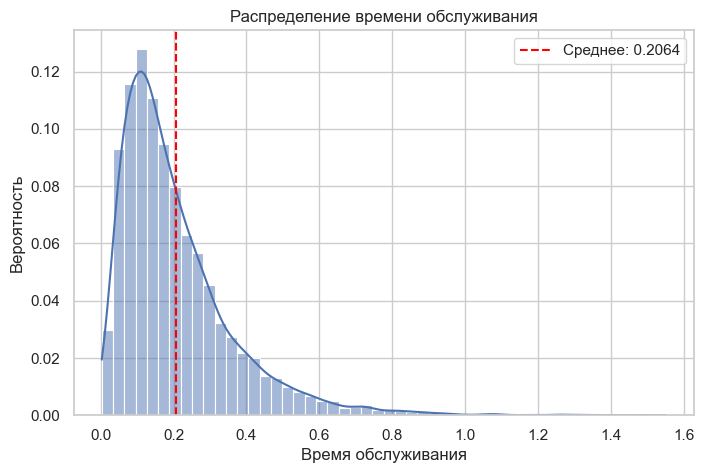

In [65]:
plt.figure(figsize=(8,5))
sns.histplot(
    result["service_times"],
    bins=50,
    kde=True,
    stat="probability"
)
plt.title("Распределение времени обслуживания")
plt.xlabel("Время обслуживания")
plt.ylabel("Вероятность")
plt.axvline(x=np.mean(result["service_times"]), color='red', linestyle='--', 
            label=f'Среднее: {np.mean(result["service_times"]):.4f}')
plt.legend()
plt.show()

## Влияние интенсивности входящего потока

In [ ]:
# Эксперимент с различной интенсивностью входящего потока
lambdas = np.linspace(1, 20, 20)

sim_wait_lambda = []
sim_queue_lambda = []
theory_wait_lambda = []
theory_queue_lambda = []
utilizations = []

for l in lambdas:
    sim = simulate_mm_n_infinity(l, mu_rpc, mu_resp, n_channels, T, database_size)
    sim_wait_lambda.append(sim["mean_wait_time"])
    sim_queue_lambda.append(sim["mean_queue_length"])
    
    t = theoretical_characteristics(l, mu_eff, n_channels)
    theory_wait_lambda.append(t["W_q"])
    theory_queue_lambda.append(t["L_q"])
    
    utilizations.append(l / mu_eff)

In [67]:
lambda_results = pd.DataFrame({
    "lambda": lambdas,
    "sim_wait": sim_wait_lambda,
    "theory_wait": theory_wait_lambda,
    "sim_queue": sim_queue_lambda,
    "theory_queue": theory_queue_lambda,
    "utilization": utilizations
})

lambda_results.head()

,lambda,sim_wait,theory_wait,sim_queue,theory_queue,utilization
0,1.0,0.000000,0.000004,1.180428,0.000004,0.206287
1,2.0,0.000021,0.000051,1.425287,0.000102,0.412575
2,3.0,0.000262,0.000238,1.600338,0.000713,0.618862
3,4.0,0.000813,0.000692,1.840551,0.002770,0.825149
4,5.0,0.001146,0.001572,2.005441,0.007858,1.031436


### Время ожидания от интенсивности входящего потока

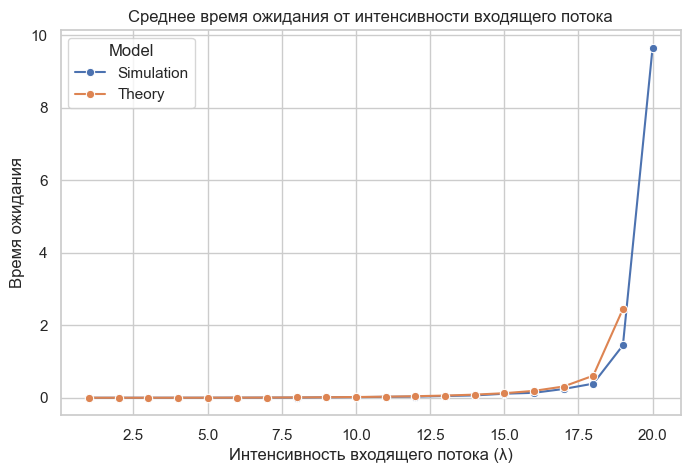

In [68]:
df_wait_lam = pd.DataFrame({
    "lambda": lambdas,
    "Simulation": sim_wait_lambda,
    "Theory": theory_wait_lambda
})

df_wait_lam_melt = df_wait_lam.melt(id_vars="lambda", 
                                     var_name="Model", 
                                     value_name="Wait time")

plt.figure(figsize=(8,5))
sns.lineplot(
    data=df_wait_lam_melt,
    x="lambda",
    y="Wait time",
    hue="Model",
    marker="o"
)
plt.title("Среднее время ожидания от интенсивности входящего потока")
plt.xlabel("Интенсивность входящего потока (λ)")
plt.ylabel("Время ожидания")
plt.show()

### Загрузка системы от интенсивности входящего потока

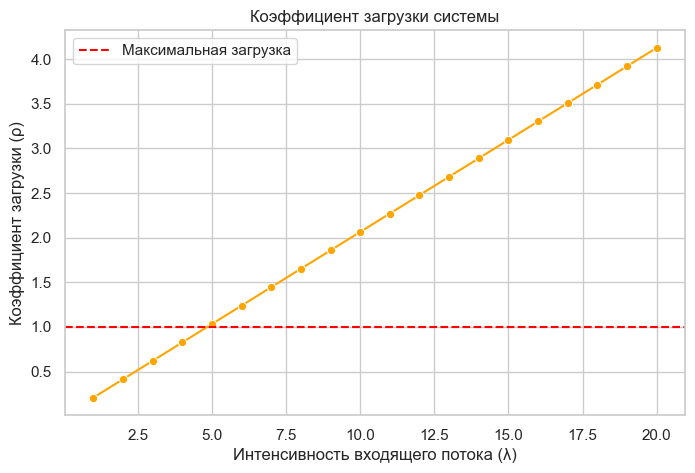

In [69]:
df_util = pd.DataFrame({
    "lambda": lambdas,
    "Utilization": utilizations
})

plt.figure(figsize=(8,5))
sns.lineplot(
    data=df_util,
    x="lambda",
    y="Utilization",
    marker="o",
    color="orange"
)
plt.axhline(y=1.0, color='red', linestyle='--', label='Максимальная загрузка')
plt.title("Коэффициент загрузки системы")
plt.xlabel("Интенсивность входящего потока (λ)")
plt.ylabel("Коэффициент загрузки (ρ)")
plt.legend()
plt.show()

### Длина очереди от интенсивности входящего потока

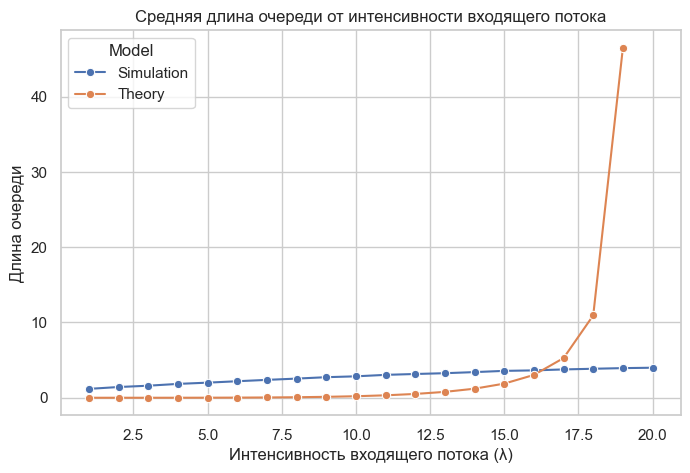

In [70]:
df_queue_lam = pd.DataFrame({
    "lambda": lambdas,
    "Simulation": sim_queue_lambda,
    "Theory": theory_queue_lambda
})

df_queue_lam_melt = df_queue_lam.melt(id_vars="lambda", 
                                      var_name="Model", 
                                      value_name="Queue length")

plt.figure(figsize=(8,5))
sns.lineplot(
    data=df_queue_lam_melt,
    x="lambda",
    y="Queue length",
    hue="Model",
    marker="o"
)
plt.title("Средняя длина очереди от интенсивности входящего потока")
plt.xlabel("Интенсивность входящего потока (λ)")
plt.ylabel("Длина очереди")
plt.show()

## Временная диаграмма работы системы

In [ ]:
def plot_timeline_mm_n(result, T, n_channels):
    requests_info = result['requests_info']
    colors = {'SET': '#2ecc71', 'GET': '#3498db', 'DELETE': '#e74c3c'}
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10),
                                   gridspec_kw={'height_ratios': [4, 1]})
    
    channel_requests = {i: [] for i in range(n_channels)}
    for req in requests_info:
        channel_requests[req['channel']].append(req)
    
    for ch in range(n_channels):
        for req in channel_requests[ch]:
            if req['status'] == 'served':
                rect = Rectangle((req['start_time'], ch + 0.2),
                                req['end_time'] - req['start_time'], 0.6,
                                facecolor=colors[req['command']],
                                edgecolor='black', alpha=0.7)
                ax1.add_patch(rect)
                
                rpc_rect = Rectangle((req['start_time'], ch + 0.2),
                                   req['rpc_time'], 0.6,
                                   facecolor=colors[req['command']],
                                   edgecolor='black', alpha=0.9)
                ax1.add_patch(rpc_rect)
                
                exec_rect = Rectangle((req['start_time'] + req['rpc_time'], ch + 0.2),
                                     req['exec_time'], 0.6,
                                     facecolor=colors[req['command']],
                                     edgecolor='black', alpha=0.7)
                ax1.add_patch(exec_rect)
                
                resp_rect = Rectangle((req['start_time'] + req['rpc_time'] + req['exec_time'], ch + 0.2),
                                     req['resp_time'], 0.6,
                                     facecolor=colors[req['command']],
                                     edgecolor='black', alpha=0.5)
                ax1.add_patch(resp_rect)
                
                if req['wait_time'] > 0:
                    ax1.plot([req['arrival_time'], req['start_time']],
                            [ch + 0.5, ch + 0.5],
                            color='gray', linestyle=':', linewidth=1)
                    ax1.plot(req['arrival_time'], ch + 0.5, '>',
                            color='blue', markersize=8)
                else:
                    ax1.plot([req['arrival_time'], req['arrival_time']],
                            [ch - 0.1, ch + 0.9],
                            color='black', linestyle='--', linewidth=1)
    
    ax1.set_xlim(0, T)
    ax1.set_ylim(-0.5, n_channels - 0.5)
    ax1.set_xlabel('Время')
    ax1.set_ylabel('Номер канала')
    ax1.set_title(f'Временная диаграмма работы системы (n={n_channels} каналов)')
    ax1.set_yticks(range(n_channels))
    ax1.set_yticklabels([f'Канал {i+1}' for i in range(n_channels)])
    ax1.grid(True, alpha=0.3)
    
    legend_elements = [mpatches.Patch(color=color, label=cmd, alpha=0.7)
                      for cmd, color in colors.items()]
    legend_elements.extend([
        mpatches.Patch(color='black', alpha=0.9, label='RPC фаза'),
        mpatches.Patch(color='black', alpha=0.7, label='Execution фаза'),
        mpatches.Patch(color='black', alpha=0.5, label='Response фаза'),
        plt.Line2D([0], [0], linestyle='--', color='black', label='Прибытие (без ожидания)'),
        plt.Line2D([0], [0], linestyle=':', color='gray', label='Ожидание в очереди')
    ])
    ax1.legend(handles=legend_elements, loc='upper right')
    
    time_points = np.linspace(0, T, 500)
    channel_loads = [[] for _ in range(n_channels)]
    
    for t in time_points:
        for ch in range(n_channels):
            busy = any(r['start_time'] <= t <= r['end_time']
                      for r in channel_requests[ch])
            channel_loads[ch].append(1 if busy else 0)
    
    ax2.stackplot(time_points, channel_loads,
                 labels=[f'Канал {i+1}' for i in range(n_channels)],
                 alpha=0.7)
    ax2.set_xlim(0, T)
    ax2.set_ylim(0, n_channels)
    ax2.set_xlabel('Время')
    ax2.set_ylabel('Количество занятых каналов')
    ax2.set_title('Загрузка каналов')
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()

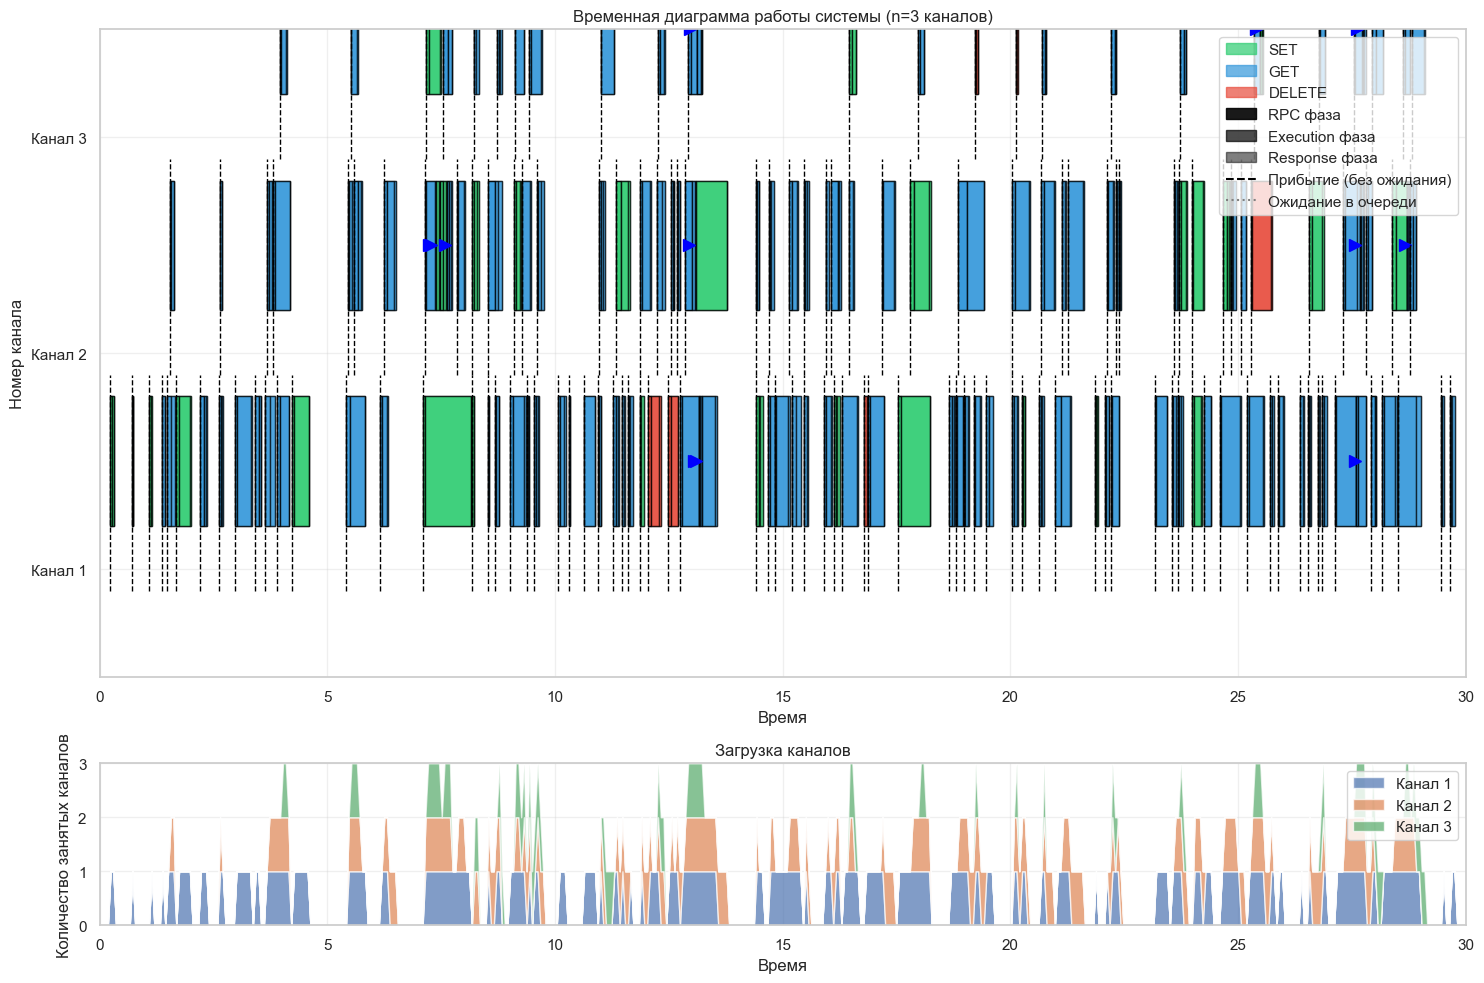

In [ ]:
timeline_result = simulate_mm_n_infinity(
    lam=5,
    mu_rpc=30,
    mu_resp=40,
    n_channels=3,
    T=30,
    db_size=1000
)

plot_timeline_mm_n(timeline_result, T=30, n_channels=3)

## Выводы

### Основные результаты:

1. **Модель M/M/n/∞** корректно описывает многоканальную систему с очередью.

2. **Влияние количества каналов:**
   - Увеличение количества каналов уменьшает время ожидания и длину очереди
   - При n ≥ λ/μ система работает стабильно с минимальной очередью

3. **Влияние интенсивности входящего потока:**
   - При λ → nμ время ожидания и длина очереди растут экспоненциально
   - Система становится неэффективной при λ близкой к nμ

4. **Согласование с теорией:**
   - Результаты имитации хорошо согласуются с формулами Эрланга-C
   - Небольшие отклонения объясняются случайным характером моделирования